In [7]:
!pip install -q mlflow

In [2]:
import json
import ast
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_score, recall_score, accuracy_score, confusion_matrix, classification_report
import torch
from torch import nn
from torch.utils.data import Dataset, TensorDataset, DataLoader
import mlflow
import mlflow.pytorch

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
import ast
import seaborn as sns
from pathlib import Path

In [4]:
random_state = 67
np.random.seed(random_state)
torch.manual_seed(random_state)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

os.symlink('/content/drive/MyDrive/GP5/yelp_academic_dataset_review.json (1).zip', '/content/yelp_reviews.zip')
os.symlink('/content/drive/MyDrive/GP5/yelp_academic_dataset_business.json.zip', '/content/yelp_business.zip')

FileExistsError: [Errno 17] File exists: '/content/drive/MyDrive/GP5/yelp_academic_dataset_review.json (1).zip' -> '/content/yelp_reviews.zip'

In [ ]:
!unzip -p /content/yelp_reviews.zip > /content/yelp_reviews.json

In [ ]:
!unzip -p /content/yelp_business.zip > /content/yelp_business.json

In [11]:
df_business = pd.read_json('/content/yelp_business.json', lines=True)
df_business.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."


In [12]:
restaurants_df = df_business[df_business['categories'].str.contains('Restaurants', case=False, na=False)]
r_ids = set(restaurants_df['business_id'])

chunks = []
for ch in pd.read_json('/content/yelp_reviews.json', lines=True, chunksize=100000):
    ch = ch[ch['business_id'].isin(r_ids)].copy()
    if not ch.empty:
        ch['date'] = pd.to_datetime(ch['date'])
        chunks.append(ch)

rev = pd.concat(chunks, ignore_index=True)
rev.shape

(4724471, 9)

In [13]:
rev.head()

,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
2,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
3,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15
4,JrIxlS1TzJ-iCu79ul40cQ,eUta8W_HdHMXPzLBBZhL1A,04UD14gamNjLY0IDYVhHJg,1,1,2,1,I am a long term frequent customer of this est...,2015-09-23 23:10:31


In [14]:
rev = rev[~((rev['cool'] == -1) | (rev['funny'] == -1) | (rev['useful'] == -1))]

In [ ]:
!pip install torch==2.2.2 torchaudio==2.2.2 torchvision==0.17.2 torchtext==0.17.2 torchdata==0.11.0

In [ ]:
!pip install portalocker==2.8.2

In [ ]:
!pip install numpy==1.26.4

In [5]:
import numpy
print(numpy.__version__)

1.26.4


In [16]:
rev = rev[['business_id', 'text', 'stars', 'date']]
df_business = df_business[['business_id', 'is_open']]

In [17]:
df = rev.merge(df_business, on='business_id', how='inner')

In [18]:
df.shape

(4724470, 5)

In [19]:
df['date'] = pd.to_datetime(df['date'])

last_review_date = df.groupby('business_id')['date'].max().reset_index()
last_review_date.rename(columns={'date': 'last_review_date'}, inplace=True)

df = df.merge(last_review_date, on='business_id', how='left')

In [20]:
df['cutoff_date'] = df['last_review_date'] - pd.Timedelta(days=180)

df_filtered = df[df['date'] >= df['cutoff_date']].copy()

In [21]:
df_filtered.drop(columns=['cutoff_date', 'last_review_date'], inplace=True)

In [22]:
df_filtered.shape

(333734, 5)

/tmp/ipykernel_48180/2085917986.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_counts.index, y=group_counts.values, palette=['green', 'red'])


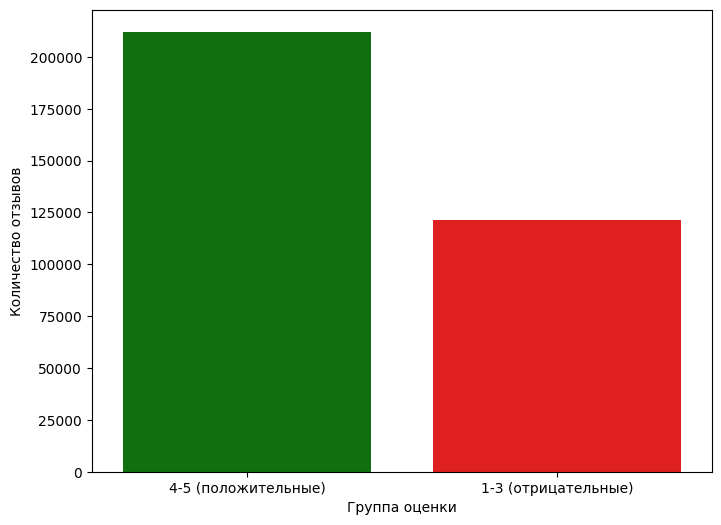

In [23]:
df_filtered['rating_group'] = '4-5 (положительные)'
df_filtered.loc[df_filtered['stars'] <= 3.5, 'rating_group'] = '1-3 (отрицательные)'

group_counts = df_filtered['rating_group'].value_counts()

plt.figure(figsize=(8,6))
sns.barplot(x=group_counts.index, y=group_counts.values, palette=['green', 'red'])
plt.xlabel('Группа оценки')
plt.ylabel('Количество отзывов')
plt.show()

In [24]:
df_filtered.drop(columns=['rating_group'], inplace=True)

/tmp/ipykernel_48180/3494992408.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_counts.index, y=group_counts.values, palette=['red', 'green'])


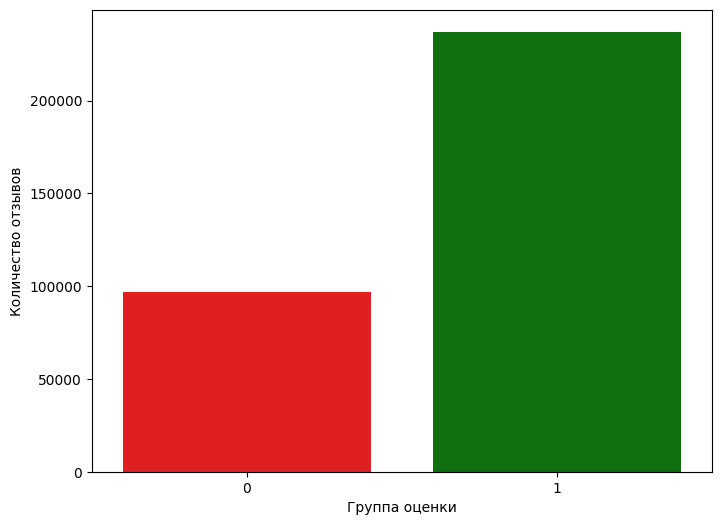

In [25]:
group_counts = df_filtered['is_open'].value_counts()

plt.figure(figsize=(8,6))
sns.barplot(x=group_counts.index, y=group_counts.values, palette=['red', 'green'])
plt.xlabel('Группа оценки')
plt.ylabel('Количество отзывов')
plt.show()

In [26]:
import re
df_filtered['text_clean'] = df_filtered['text'].str.lower().str.replace(r'[^a-z0-9\s\!\?]', ' ', regex=True).str.replace(r'\s+', ' ', regex=True).str.strip()
df_filtered.text_clean.unique()

array(['the ramen is okay nothing spectacular service is okay good place for a quick stop but wouldn t go if there were other choices been here twice will continue to go',
       'i stopped in for dinner and a drink was thoroughly pleased! i rarely order a burger when i go out to eat because why order out what you can make easily a home right? well when i go back i ll have a hard time not getting another burger oh they also have a decent beer selection and the wait staff bartenders made me feel very welcomed too my food was prepared exactly as i ordered and was served quickly the restaurant has a nice atmosphere and the restrooms were clean all in all i was very happy!',
       'they reopened up derived new management this was our 3rd time there they have daily specials which is a pretty good price 7 95 for a plate ice tea and soup todays friday special they had carne asada with rice n beans fried fish plate and 2 chicken enchiladas with rice n beans all come with tea n soup we both ha

In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 --quiet

In [ ]:
!pip install transformers

In [6]:
from transformers import BertTokenizerFast
import torch

In [28]:
print("PyTorch версия:", torch.__version__)
print("Есть ли GPU:", torch.cuda.is_available())

PyTorch версия: 2.2.2+cu118
Есть ли GPU: False


In [ ]:
!pip uninstall torch torchvision torchaudio transformers -y

Found existing installation: torch 2.2.2+cu118
Uninstalling torch-2.2.2+cu118:
  Successfully uninstalled torch-2.2.2+cu118
Found existing installation: torchvision 0.17.2+cu118
Uninstalling torchvision-0.17.2+cu118:
  Successfully uninstalled torchvision-0.17.2+cu118
Found existing installation: torchaudio 2.2.2+cu118
Uninstalling torchaudio-2.2.2+cu118:
  Successfully uninstalled torchaudio-2.2.2+cu118
Found existing installation: transformers 4.41.2
Uninstalling transformers-4.41.2:
  Successfully uninstalled transformers-4.41.2


In [ ]:
!pip uninstall torch torchvision torchaudio transformers sentence-transformers peft torchtext -y

Found existing installation: sentence-transformers 2.5.0
Uninstalling sentence-transformers-2.5.0:
  Successfully uninstalled sentence-transformers-2.5.0
Found existing installation: peft 0.10.0
Uninstalling peft-0.10.0:
  Successfully uninstalled peft-0.10.0
Found existing installation: torchtext 0.17.2
Uninstalling torchtext-0.17.2:
  Successfully uninstalled torchtext-0.17.2


In [ ]:
!pip install torch==2.2.2 torchvision==0.17.2 torchaudio==2.2.2 --index-url https://download.pytorch.org/whl/cu118 --quiet

In [ ]:
!pip install transformers==4.41.2 --quiet

In [ ]:
!pip install sentence-transformers==2.5.0 peft==0.10.0 torchtext==0.17.2 --quiet

In [7]:
from transformers import BertTokenizerFast
import torch

In [30]:
print("PyTorch версия:", torch.__version__)
print("Есть ли GPU:", torch.cuda.is_available())

PyTorch версия: 2.2.2+cu118
Есть ли GPU: False


In [31]:
review_counts = df_filtered['business_id'].value_counts()

valid_business_ids = review_counts[review_counts >= 10].index

df_final = df_filtered[df_filtered['business_id'].isin(valid_business_ids)].copy().reset_index()

In [32]:
df_final.shape

(189125, 7)

/tmp/ipykernel_48180/1843336949.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_counts.index, y=group_counts.values, palette=['green', 'red'])


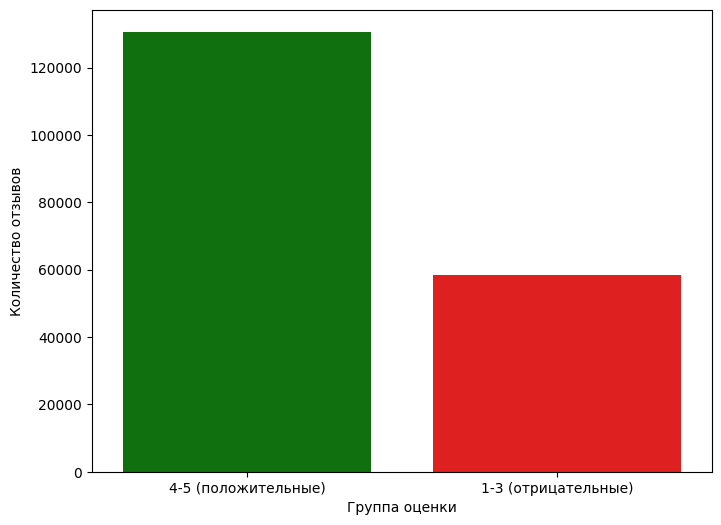

In [33]:
df_final['rating_group'] = '4-5 (положительные)'
df_final.loc[df_final['stars'] <= 3.5, 'rating_group'] = '1-3 (отрицательные)'

group_counts = df_final['rating_group'].value_counts()

plt.figure(figsize=(8,6))
sns.barplot(x=group_counts.index, y=group_counts.values, palette=['green', 'red'])
plt.xlabel('Группа оценки')
plt.ylabel('Количество отзывов')
plt.show()

In [34]:
df_final.drop(columns=['rating_group'], inplace=True)

/tmp/ipykernel_48180/611639368.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_counts.index, y=group_counts.values, palette=['red', 'green'])


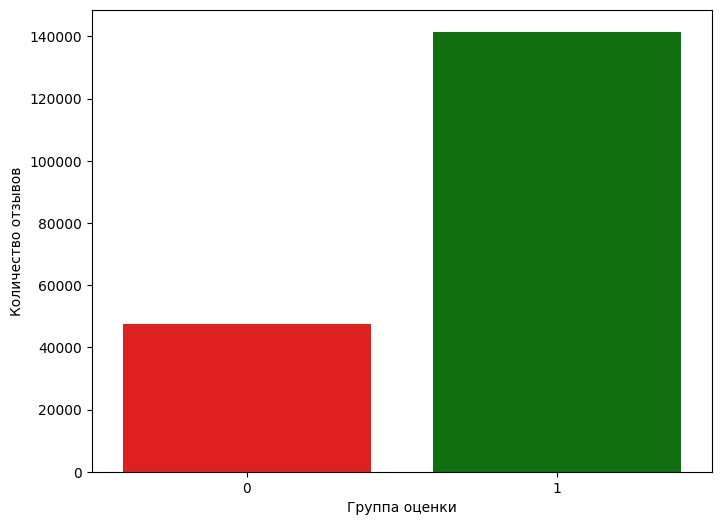

In [35]:
group_counts = df_final['is_open'].value_counts()

plt.figure(figsize=(8,6))
sns.barplot(x=group_counts.index, y=group_counts.values, palette=['red', 'green'])
plt.xlabel('Группа оценки')
plt.ylabel('Количество отзывов')
plt.show()

In [36]:
df_final.head()

,index,business_id,text,stars,date,is_open,text_clean
0,80,uaipZDBSvzDzUUlazpyGCg,"The ramen is okay, nothing spectacular. Servic...",3,2016-01-04 07:26:09,0,the ramen is okay nothing spectacular service ...
1,291,1_nd9Hcswx4K4FmZZQPMVw,Rosemary's Grill is my favorite resaurant. My...,5,2014-02-24 11:13:47,0,rosemary s grill is my favorite resaurant my w...
2,311,R77LwVI3wPAFmDLrXt3zZA,I love this restaurant. The owners are the nic...,5,2018-04-15 15:46:22,0,i love this restaurant the owners are the nice...
3,501,NMtUD873aWrNjljt3VOcFA,Chef Kevin Sbraga knows fried chicken. My firs...,4,2015-04-28 19:43:37,0,chef kevin sbraga knows fried chicken my first...
4,504,-e9MepGs8piOYdwuP5x7tw,"Tasty brunch, extremely friendly staff, great ...",5,2016-05-07 06:33:39,0,tasty brunch extremely friendly staff great co...


Text(0, 0.5, 'Количество заведений')

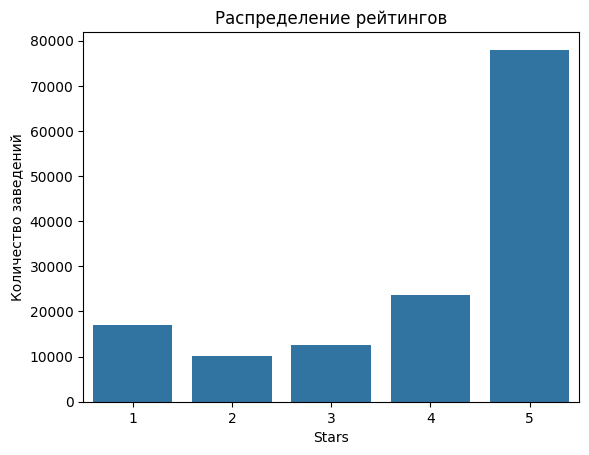

In [37]:
df_open = df_final[df_final['is_open'] == 1]

plt.figure()
sns.countplot(data=df_open, x='stars', order=sorted(df_open['stars'].unique()))
plt.title('Распределение рейтингов')
plt.xlabel('Stars')
plt.ylabel('Количество заведений')

Text(0, 0.5, 'Количество заведений')

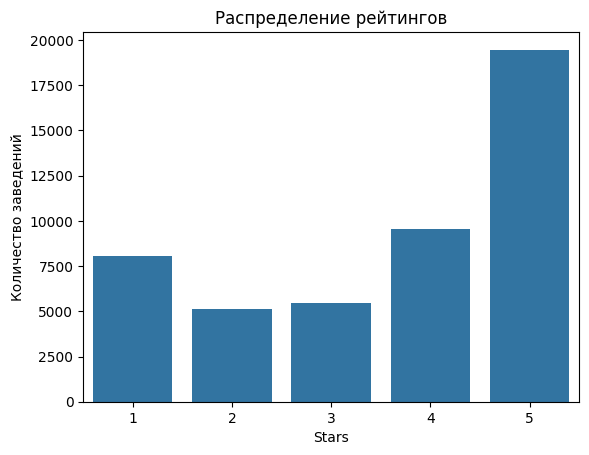

In [38]:
df_close = df_final[df_final['is_open'] == 0]

plt.figure()
sns.countplot(data=df_close, x='stars', order=sorted(df_close['stars'].unique()))
plt.title('Распределение рейтингов')
plt.xlabel('Stars')
plt.ylabel('Количество заведений')

In [39]:
from tqdm import tqdm
# чтобы я могла видеть прогресс, а то я че то не вкуривала оно вообще работает или нет

# я применяю быструю BERT токенизацию
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

texts = df_final['text_clean'].astype(str).tolist()

batch_size = 1000 # поделила на батчи, чтобы быстрее работал, а то даже на 600к строках долго было
lengths = [] # для статистики длина токена

for i in tqdm(range(0, len(texts), batch_size)):
    batch = texts[i:i+batch_size]
    encodings = tokenizer(batch, add_special_tokens=True, truncation=True, padding=False)
    for ids in encodings['input_ids']:
        lengths.append(len(ids))

df_final['token_len'] = lengths

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
100%|██████████| 190/190 [01:35<00:00,  2.00it/s]


In [40]:
df_final

,index,business_id,text,stars,date,is_open,text_clean,token_len
0,80,uaipZDBSvzDzUUlazpyGCg,"The ramen is okay, nothing spectacular. Servic...",3,2016-01-04 07:26:09,0,the ramen is okay nothing spectacular service ...,34
1,291,1_nd9Hcswx4K4FmZZQPMVw,Rosemary's Grill is my favorite resaurant. My...,5,2014-02-24 11:13:47,0,rosemary s grill is my favorite resaurant my w...,382
2,311,R77LwVI3wPAFmDLrXt3zZA,I love this restaurant. The owners are the nic...,5,2018-04-15 15:46:22,0,i love this restaurant the owners are the nice...,43
3,501,NMtUD873aWrNjljt3VOcFA,Chef Kevin Sbraga knows fried chicken. My firs...,4,2015-04-28 19:43:37,0,chef kevin sbraga knows fried chicken my first...,252
4,504,-e9MepGs8piOYdwuP5x7tw,"Tasty brunch, extremely friendly staff, great ...",5,2016-05-07 06:33:39,0,tasty brunch extremely friendly staff great co...,45
...,...,...,...,...,...,...,...,...
189120,4724455,B2xtWMBTyDtd-ndqqaIC1Q,Sat at the bar for 10 minutes and didn't get s...,1,2022-01-15 15:41:15,1,sat at the bar for 10 minutes and didn t get s...,45
189121,4724457,c3QxX3toWdqJnKQmmIliRQ,"The supper club is ridiculously expensive. So,...",1,2021-11-29 18:26:40,1,the supper club is ridiculously expensive so w...,82
189122,4724463,uMVOtr16r1ELu46pWr4HCQ,Just average Thai food tonight. Bangkok has al...,1,2022-01-18 06:42:59,1,just average thai food tonight bangkok has alw...,181
189123,4724466,e_E-jq9mwm7wk75k7Yi-Xw,It is very rare for a restaurant to be this go...,5,2022-01-17 22:36:01,1,it is very rare for a restaurant to be this go...,69


In [41]:
# тут я уже создаю сами токены и маску для будущего обучения и кладу в датафрейм
ids_list = []
masks_list = []
max_len = int(df_final['token_len'].quantile(0.95)) # тк я не знаю какую длину взять, то возьмем такой перцентиль, чтобы не обрезать сильно слишком длинные отзывы

for i in tqdm(range(0, len(texts), batch_size)):
    batch = texts[i:i+batch_size]
    encodings = tokenizer(batch, add_special_tokens=True, truncation=True, max_length=max_len, padding='max_length', return_tensors=None)
    ids_list.extend(encodings['input_ids'])
    masks_list.extend(encodings['attention_mask'])

df_final['input_ids'] = ids_list
df_final['attention_mask'] = masks_list

100%|██████████| 190/190 [01:50<00:00,  1.72it/s]


In [42]:
df_final

,index,business_id,text,stars,date,is_open,text_clean,token_len,input_ids,attention_mask
0,80,uaipZDBSvzDzUUlazpyGCg,"The ramen is okay, nothing spectacular. Servic...",3,2016-01-04 07:26:09,0,the ramen is okay nothing spectacular service ...,34,"[101, 1996, 8223, 2368, 2003, 3100, 2498, 1265...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,291,1_nd9Hcswx4K4FmZZQPMVw,Rosemary's Grill is my favorite resaurant. My...,5,2014-02-24 11:13:47,0,rosemary s grill is my favorite resaurant my w...,382,"[101, 18040, 1055, 18651, 2003, 2026, 5440, 24...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
2,311,R77LwVI3wPAFmDLrXt3zZA,I love this restaurant. The owners are the nic...,5,2018-04-15 15:46:22,0,i love this restaurant the owners are the nice...,43,"[101, 1045, 2293, 2023, 4825, 1996, 5608, 2024...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,501,NMtUD873aWrNjljt3VOcFA,Chef Kevin Sbraga knows fried chicken. My firs...,4,2015-04-28 19:43:37,0,chef kevin sbraga knows fried chicken my first...,252,"[101, 10026, 4901, 24829, 29181, 2050, 4282, 1...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,504,-e9MepGs8piOYdwuP5x7tw,"Tasty brunch, extremely friendly staff, great ...",5,2016-05-07 06:33:39,0,tasty brunch extremely friendly staff great co...,45,"[101, 11937, 21756, 7987, 4609, 2818, 5186, 53...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
...,...,...,...,...,...,...,...,...,...,...
189120,4724455,B2xtWMBTyDtd-ndqqaIC1Q,Sat at the bar for 10 minutes and didn't get s...,1,2022-01-15 15:41:15,1,sat at the bar for 10 minutes and didn t get s...,45,"[101, 2938, 2012, 1996, 3347, 2005, 2184, 2781...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
189121,4724457,c3QxX3toWdqJnKQmmIliRQ,"The supper club is ridiculously expensive. So,...",1,2021-11-29 18:26:40,1,the supper club is ridiculously expensive so w...,82,"[101, 1996, 15264, 2252, 2003, 9951, 2135, 645...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
189122,4724463,uMVOtr16r1ELu46pWr4HCQ,Just average Thai food tonight. Bangkok has al...,1,2022-01-18 06:42:59,1,just average thai food tonight bangkok has alw...,181,"[101, 2074, 2779, 7273, 2833, 3892, 12627, 203...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
189123,4724466,e_E-jq9mwm7wk75k7Yi-Xw,It is very rare for a restaurant to be this go...,5,2022-01-17 22:36:01,1,it is very rare for a restaurant to be this go...,69,"[101, 2009, 2003, 2200, 4678, 2005, 1037, 4825...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


In [43]:
df_final.to_csv('final.csv', encoding='utf-8',  index=False,)

In [8]:
df_final=pd.read_csv('final.csv', encoding='utf-8')

In [9]:
df_final

,index,business_id,text,stars,date,is_open,text_clean,token_len,input_ids,attention_mask
0,80,uaipZDBSvzDzUUlazpyGCg,"The ramen is okay, nothing spectacular. Servic...",3,2016-01-04 07:26:09,0,the ramen is okay nothing spectacular service ...,34,"[101, 1996, 8223, 2368, 2003, 3100, 2498, 1265...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,291,1_nd9Hcswx4K4FmZZQPMVw,Rosemary's Grill is my favorite resaurant. My...,5,2014-02-24 11:13:47,0,rosemary s grill is my favorite resaurant my w...,382,"[101, 18040, 1055, 18651, 2003, 2026, 5440, 24...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
2,311,R77LwVI3wPAFmDLrXt3zZA,I love this restaurant. The owners are the nic...,5,2018-04-15 15:46:22,0,i love this restaurant the owners are the nice...,43,"[101, 1045, 2293, 2023, 4825, 1996, 5608, 2024...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,501,NMtUD873aWrNjljt3VOcFA,Chef Kevin Sbraga knows fried chicken. My firs...,4,2015-04-28 19:43:37,0,chef kevin sbraga knows fried chicken my first...,252,"[101, 10026, 4901, 24829, 29181, 2050, 4282, 1...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,504,-e9MepGs8piOYdwuP5x7tw,"Tasty brunch, extremely friendly staff, great ...",5,2016-05-07 06:33:39,0,tasty brunch extremely friendly staff great co...,45,"[101, 11937, 21756, 7987, 4609, 2818, 5186, 53...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
...,...,...,...,...,...,...,...,...,...,...
189120,4724455,B2xtWMBTyDtd-ndqqaIC1Q,Sat at the bar for 10 minutes and didn't get s...,1,2022-01-15 15:41:15,1,sat at the bar for 10 minutes and didn t get s...,45,"[101, 2938, 2012, 1996, 3347, 2005, 2184, 2781...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
189121,4724457,c3QxX3toWdqJnKQmmIliRQ,"The supper club is ridiculously expensive. So,...",1,2021-11-29 18:26:40,1,the supper club is ridiculously expensive so w...,82,"[101, 1996, 15264, 2252, 2003, 9951, 2135, 645...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
189122,4724463,uMVOtr16r1ELu46pWr4HCQ,Just average Thai food tonight. Bangkok has al...,1,2022-01-18 06:42:59,1,just average thai food tonight bangkok has alw...,181,"[101, 2074, 2779, 7273, 2833, 3892, 12627, 203...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
189123,4724466,e_E-jq9mwm7wk75k7Yi-Xw,It is very rare for a restaurant to be this go...,5,2022-01-17 22:36:01,1,it is very rare for a restaurant to be this go...,69,"[101, 2009, 2003, 2200, 4678, 2005, 1037, 4825...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


In [10]:
import mlflow
import mlflow.pytorch
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
import numpy as np
import pandas as pd
import ast
from tqdm import tqdm
import matplotlib.pyplot as plt
import os

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("textcnn")

use_mlflow = True
artifact_dir = Path("mlflow_artifacts_textcnn")
artifact_dir.mkdir(exist_ok=True)

In [11]:
class RestaurantDataset(Dataset):
    def __init__(self, df):
        self.input_ids = torch.tensor(np.array(df['input_ids'].tolist()), dtype=torch.long)
        self.attention_mask = torch.tensor(np.array(df['attention_mask'].tolist()), dtype=torch.long)
        self.is_open = torch.tensor(df['is_open'].values, dtype=torch.long)

    def __len__(self):
        return len(self.is_open)

    def __getitem__(self, idx):
        return {
            'input_ids': self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'is_open': self.is_open[idx]
        }

In [12]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, num_filters=128, filter_sizes=[3, 4, 5], num_classes=2, dropout=0.5):
        super(TextCNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, fs) for fs in filter_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(len(filter_sizes) * num_filters, num_classes)

    def forward(self, input_ids, attention_mask=None):
        x = self.embedding(input_ids)
        x = x.permute(0, 2, 1)

        conv_outputs = []
        for conv in self.convs:
            c = F.relu(conv(x))
            c = F.max_pool1d(c, c.size(2)).squeeze(2)
            conv_outputs.append(c)

        x = torch.cat(conv_outputs, dim=1)
        x = self.dropout(x)
        return self.fc(x)

In [13]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    for batch in tqdm(loader, desc="Train"):
        ids = batch['input_ids'].to(device)
        labels = batch['is_open'].to(device)
        optimizer.zero_grad()
        logits = model(ids)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary')
    return avg_loss, acc, prec, rec, f1

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc="Eval"):
            ids = batch['input_ids'].to(device)
            labels = batch['is_open'].to(device)
            logits = model(ids)
            loss = criterion(logits, labels)
            total_loss += loss.item()
            probs = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
            preds = (probs >= 0.5).astype(int)
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs)
    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary')
    auc = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0
    return avg_loss, acc, prec, rec, f1, auc

In [14]:
df_final['input_ids'] = df_final['input_ids'].apply(ast.literal_eval)
df_final['attention_mask'] = df_final['attention_mask'].apply(ast.literal_eval)

In [15]:
train_df, temp_df = train_test_split(df_final, test_size=0.2, random_state=42, stratify=df_final['is_open'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['is_open'])

In [16]:
all_ids = np.concatenate(df_final['input_ids'].values)
vocab_size_real = int(max(all_ids)) + 1
print(f"Размер словаря: {vocab_size_real}")
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Размер словаря: 29612
Train: 151300, Val: 18912, Test: 18913


In [17]:
config = {
    "embed_dim": 100,
    "num_filters": 128,
    "filter_sizes": [3, 4, 5],
    "dropout": 0.5,
    "batch_size": 64,
    "learning_rate": 1e-3,
    "epochs": 5,
    "vocab_size": vocab_size_real,
    "max_seq_len": 128,
    "device": "cuda" if torch.cuda.is_available() else "cpu"
}

In [18]:
train_dataset = RestaurantDataset(train_df)
val_dataset = RestaurantDataset(val_df)
test_dataset = RestaurantDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=config['batch_size'], shuffle=False)

In [ ]:
run_name = f"TextCNN_emb{config['embed_dim']}_filters{config['num_filters']}_fs{config['filter_sizes']}_lr{config['learning_rate']}_bs{config['batch_size']}"

with mlflow.start_run(run_name=run_name) as run:
    mlflow.log_params({
        "model_type": "TextCNN",
        "embed_dim": config['embed_dim'],
        "num_filters": config['num_filters'],
        "filter_sizes": str(config['filter_sizes']),
        "dropout": config['dropout'],
        "batch_size": config['batch_size'],
        "learning_rate": config['learning_rate'],
        "epochs": config['epochs'],
        "vocab_size": config['vocab_size'],
        "max_seq_len": config['max_seq_len']
    })

    model = TextCNN(
        vocab_size=config['vocab_size'],
        embed_dim=config['embed_dim'],
        num_filters=config['num_filters'],
        filter_sizes=config['filter_sizes'],
        num_classes=2,
        dropout=config['dropout']
    ).to(config['device'])

    optimizer = torch.optim.Adam(model.parameters(), lr=config['learning_rate'])
    criterion = nn.CrossEntropyLoss()

    best_val_f1 = 0.0
    best_model_state = None
    history = {"train_loss": [], "train_f1": [], "val_loss": [], "val_f1": [], "val_auc": []}

    for epoch in range(1, config['epochs'] + 1):
        train_loss, train_acc, train_prec, train_rec, train_f1 = train_epoch(
            model, train_loader, optimizer, criterion, config['device']
        )
        val_loss, val_acc, val_prec, val_rec, val_f1, val_auc = eval_epoch(
            model, val_loader, criterion, config['device']
        )

        mlflow.log_metrics({
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "train_precision": train_prec,
            "train_recall": train_rec,
            "train_f1": train_f1,
            "val_loss": val_loss,
            "val_accuracy": val_acc,
            "val_precision": val_prec,
            "val_recall": val_rec,
            "val_f1": val_f1,
            "val_roc_auc": val_auc
        }, step=epoch)

        history["train_loss"].append(train_loss)
        history["train_f1"].append(train_f1)
        history["val_loss"].append(val_loss)
        history["val_f1"].append(val_f1)
        history["val_auc"].append(val_auc)

        print(f"Epoch {epoch}: train_loss={train_loss:.4f} | val_loss={val_loss:.4f} val_f1={val_f1:.4f} val_auc={val_auc:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_state = model.state_dict().copy()

    model.load_state_dict(best_model_state)

    test_loss, test_acc, test_prec, test_rec, test_f1, test_auc = eval_epoch(
        model, test_loader, criterion, config['device']
    )
    test_metrics = {
        "test_loss": test_loss,
        "test_accuracy": test_acc,
        "test_precision": test_prec,
        "test_recall": test_rec,
        "test_f1": test_f1,
        "test_roc_auc": test_auc
    }
    mlflow.log_metrics(test_metrics)
    print(f"Тест: F1={test_f1:.4f}, AUC={test_auc:.4f}")

    os.makedirs("plots_textcnn", exist_ok=True)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 3, 1)
    plt.plot(history["train_loss"], label="Train")
    plt.plot(history["val_loss"], label="Val")
    plt.title("Loss"); plt.xlabel("Epoch"); plt.legend(); plt.grid()

    plt.subplot(1, 3, 2)
    plt.plot(history["train_f1"], label="Train")
    plt.plot(history["val_f1"], label="Val")
    plt.title("F1"); plt.xlabel("Epoch"); plt.legend(); plt.grid()

    plt.subplot(1, 3, 3)
    plt.plot(history["val_auc"], label="Val AUC", color="green")
    plt.title("ROC-AUC"); plt.xlabel("Epoch"); plt.legend(); plt.grid()
    plt.tight_layout()
    plt.savefig("plots_textcnn/metric_curves.png")
    mlflow.log_artifacts("plots_textcnn", artifact_path="metric_plots")

    mlflow.pytorch.log_model(model, "textcnn_model")

    print(f"Run ID: {run.info.run_id}")
    print(f"Лучший val F1: {best_val_f1:.4f}, тестовый F1: {test_f1:.4f}")


Eval: 100%|██████████| 296/296 [01:00<00:00,  4.92it/s]


Epoch 1: train_loss=0.5768 | val_loss=0.5383 val_f1=0.8568 val_auc=0.6777


Train:  30%|██▉       | 706/2365 [07:06<21:41,  1.27it/s]